I'd like to try plotting the GSP regions from NESO so that I can then use this map to visualize data
- EPSG:4326 (longitude/latitude - very common and geojson is convenient) and EPSG:27700 (British National Grid)
- saves outputs in data/outputs/visualisations

**Notebook purpose**

This notebook loads NESO Grid Supply Point (GSP) region boundaries and creates maps showing the locations and coverage of Met Office Global Horizontal Irradiance (GHI) instruments.

The GSP boundaries are loaded from GeoJSON in EPSG:4326 longitude/latitude coordinates. The regions are analysed for shared boundaries and coloured using a DSATUR-style graph-colouring algorithm. This assigns neighbouring GSP regions different colours, using five colours where required.

GHI station data are retrieved from the public Met Office AWS S3 bucket. The notebook searches the available observation files, selects the requested observation time where available, or otherwise uses the latest available batch. A station is treated as having GHI data when at least one value of global_radiation_1_minute_mean is present.

The GHI station coordinates are converted into GeoPandas point geometries. A spatial join then identifies which GSP polygon contains each instrument. Regions containing one or more GHI instruments retain their bright colour; regions without instruments are displayed using a much paler version of their assigned colour.

Northern Ireland, the Republic of Ireland, Guernsey, the Isle of Man, and Jersey are plotted separately using low-resolution GADM GeoJSON boundaries. These areas are shown with very light grey fills and dashed grey outlines for geographic reference, but they are not included in the GSP-region coverage counts.

The final map displays the GHI instrument points, the GSP coverage status, and summary counts for:

Total GHI instruments
Total GSP regions
GSP regions containing at least one GHI instrument
The final figure is displayed inline and exported as an SVG for use in further analysis or reports.

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

# The GeoJSON is already in longitude/latitude (EPSG:4326), which is convenient for plotting.
data_path = Path("../data/inputs/gsp_regions_20260209/Proj_4326/GSP_regions_4326_20260209.geojson")
gsp_regions = gpd.read_file(data_path)

gsp_regions.head()

,fid,GSPs,GSPGroup,SSEP17Zone,DSCPs,InGroup_,CDCA_I030,geometry
0,1,LEGA_1,_D,7,NaN,Y,=GSP_LEGA_1,"MULTIPOLYGON (((-3.67528 52.3655, -3.67033 52...."
1,2,THSO_P,_P,1,NaN,Y,=GSP_THSO_P,"MULTIPOLYGON (((-3.0732 58.73774, -3.07412 58...."
2,3,BRIM_1,_C,17,[+]BRIM_C,N,=II_BRIM_C,"MULTIPOLYGON (((0.12638 51.59359, 0.12145 51.5..."
3,4,EERH,_N,4,NaN,Y,=GSP_EERH,"MULTIPOLYGON (((-4.1545 55.84639, -4.15447 55...."
4,5,AXMI1,_L,15,NaN,Y,=GSP_AXMI1,"MULTIPOLYGON (((-2.69894 50.68317, -2.69628 50..."


In [4]:
number_of_gsp_regions = len(gsp_regions)
print(f"Number of GSP regions: {number_of_gsp_regions}")

Number of GSP regions: 362


^ not sure how to square this with OCF saying 317. Maybe OCF out of date? or using aggregated

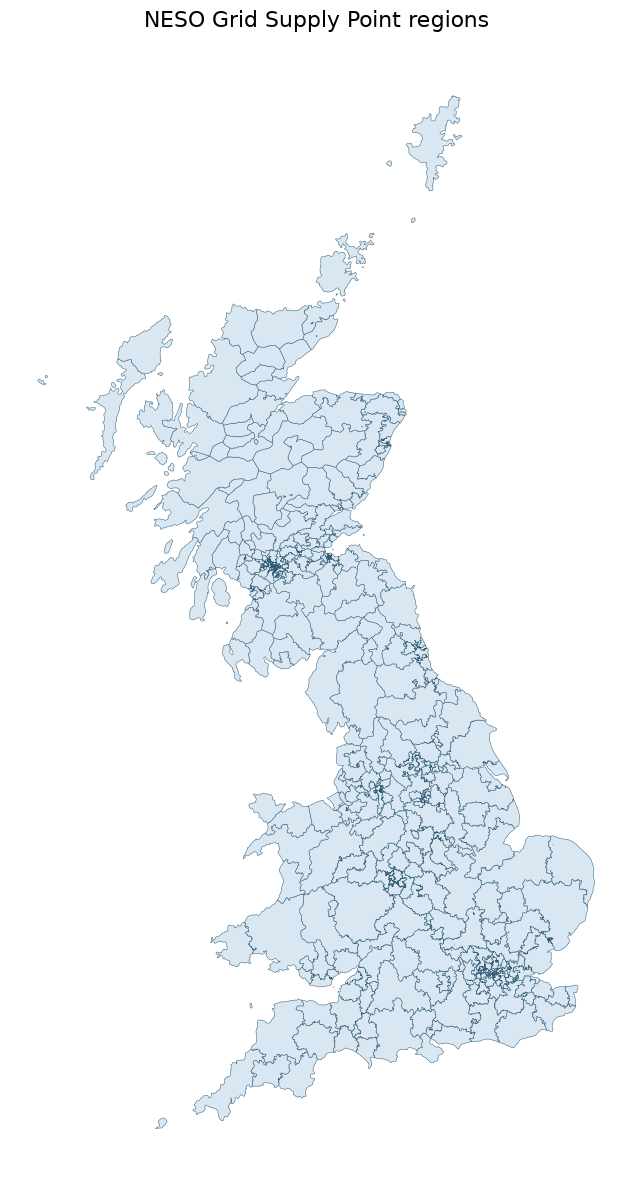

In [13]:
fig, ax = plt.subplots(figsize=(10, 12))

gsp_regions.plot(
    ax=ax,
    facecolor="#d9e7f2",
    edgecolor="#315b73",
    linewidth=0.35,
)

ax.set_title("NESO Grid Supply Point regions", fontsize=16, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [5]:
import random

# Build an adjacency graph from shared boundary segments.
adjacent_regions = {index: set() for index in range(len(gsp_regions))}
spatial_index = gsp_regions.sindex

for region_index, geometry in enumerate(gsp_regions.geometry):
    if region_index % 25 == 0:
        print(f"Checking adjacency: region {region_index + 1}/{len(gsp_regions)}")

    for neighbour_index in spatial_index.query(geometry, predicate="touches"):
        neighbour_index = int(neighbour_index)
        if neighbour_index <= region_index:
            continue

        shared_boundary = geometry.boundary.intersection(
            gsp_regions.geometry.iloc[neighbour_index].boundary
        )
        if shared_boundary.length > 1e-10:
            adjacent_regions[region_index].add(neighbour_index)
            adjacent_regions[neighbour_index].add(region_index)

print(f"Adjacency graph ready: {sum(map(len, adjacent_regions.values())) // 2} shared boundaries")

# Random tie-breaking gives DSATUR several inexpensive chances to find a compact colouring.
colour_assignments = None
for number_of_colours in (4, 5):
    for attempt in range(1, 201):
        assignments = [-1] * len(gsp_regions)
        uncoloured_regions = set(adjacent_regions)

        while uncoloured_regions:
            saturation = {
                index: len({
                    assignments[neighbour_index]
                    for neighbour_index in adjacent_regions[index]
                    if assignments[neighbour_index] != -1
                })
                for index in uncoloured_regions
            }
            highest_saturation = max(saturation.values())
            candidates = [
                index for index in uncoloured_regions
                if saturation[index] == highest_saturation
            ]
            region_index = max(
                candidates,
                key=lambda index: (len(adjacent_regions[index]), random.random()),
            )
            unavailable_colours = {
                assignments[neighbour_index]
                for neighbour_index in adjacent_regions[region_index]
                if assignments[neighbour_index] != -1
            }
            available_colours = set(range(number_of_colours)) - unavailable_colours

            if not available_colours:
                break

            assignments[region_index] = min(available_colours)
            uncoloured_regions.remove(region_index)

        if not uncoloured_regions:
            colour_assignments = assignments
            print(
                f"{number_of_colours}-colour assignment found on attempt {attempt}"
            )
            break

        if attempt % 10 == 0:
            print(
                f"{number_of_colours}-colour attempt {attempt}/200 did not fit"
            )

    if colour_assignments is not None:
        break

assert colour_assignments is not None, "Could not colour the adjacency graph."

if number_of_colours == 5:
    print("The supplied geometries need five colours under strict shared-boundary adjacency.")

# Check that every pair of adjacent regions has different colours.
assert all(
    colour_assignments[region_index] != colour_assignments[neighbour_index]
    for region_index, neighbours in adjacent_regions.items()
    for neighbour_index in neighbours
)

plot_data = gsp_regions.assign(_colour=colour_assignments)
plot_data["_colour"].value_counts().sort_index()

Checking adjacency: region 1/362
Checking adjacency: region 26/362
Checking adjacency: region 51/362
Checking adjacency: region 76/362
Checking adjacency: region 101/362
Checking adjacency: region 126/362
Checking adjacency: region 151/362
Checking adjacency: region 176/362
Checking adjacency: region 201/362
Checking adjacency: region 226/362
Checking adjacency: region 251/362
Checking adjacency: region 276/362
Checking adjacency: region 301/362
Checking adjacency: region 326/362
Checking adjacency: region 351/362
Adjacency graph ready: 975 shared boundaries
4-colour attempt 10/200 did not fit
4-colour attempt 20/200 did not fit
4-colour attempt 30/200 did not fit
4-colour attempt 40/200 did not fit
4-colour attempt 50/200 did not fit
4-colour attempt 60/200 did not fit
4-colour attempt 70/200 did not fit
4-colour attempt 80/200 did not fit
4-colour attempt 90/200 did not fit
4-colour attempt 100/200 did not fit
4-colour attempt 110/200 did not fit
4-colour attempt 120/200 did not fit


_colour
0    101
1     91
2     90
3     74
4      6
Name: count, dtype: int64

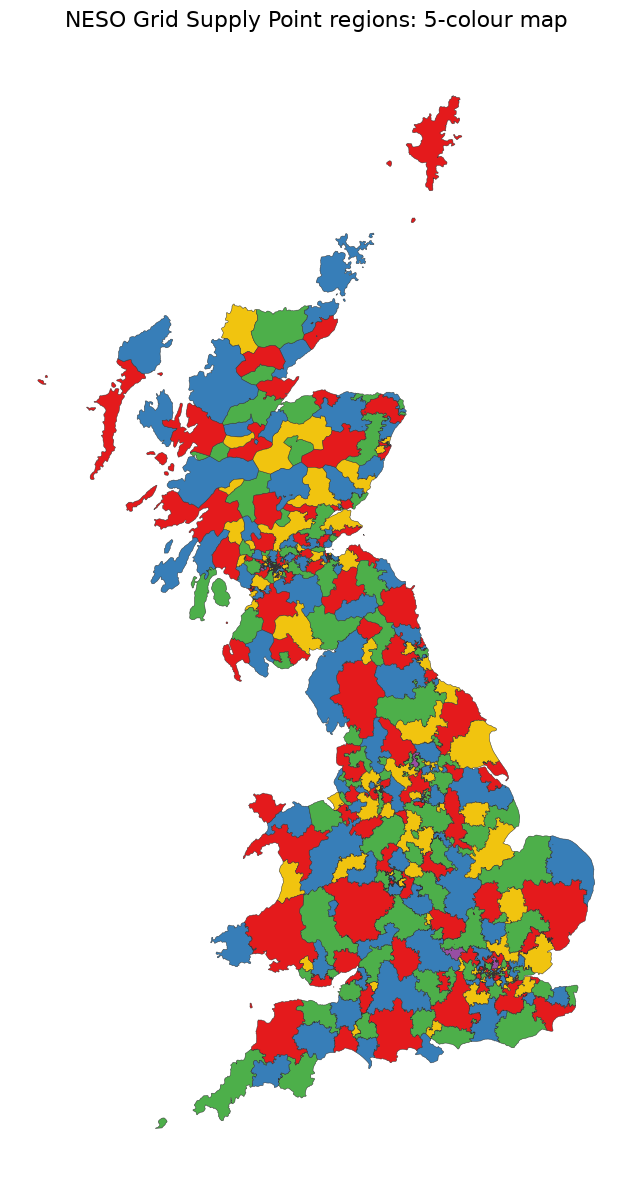

In [6]:
from matplotlib.colors import ListedColormap

colours = ["#e41a1c", "#377eb8", "#4daf4a", "#f1c40f", "#984ea3"]

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.35,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map",
    fontsize=16,
    pad=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

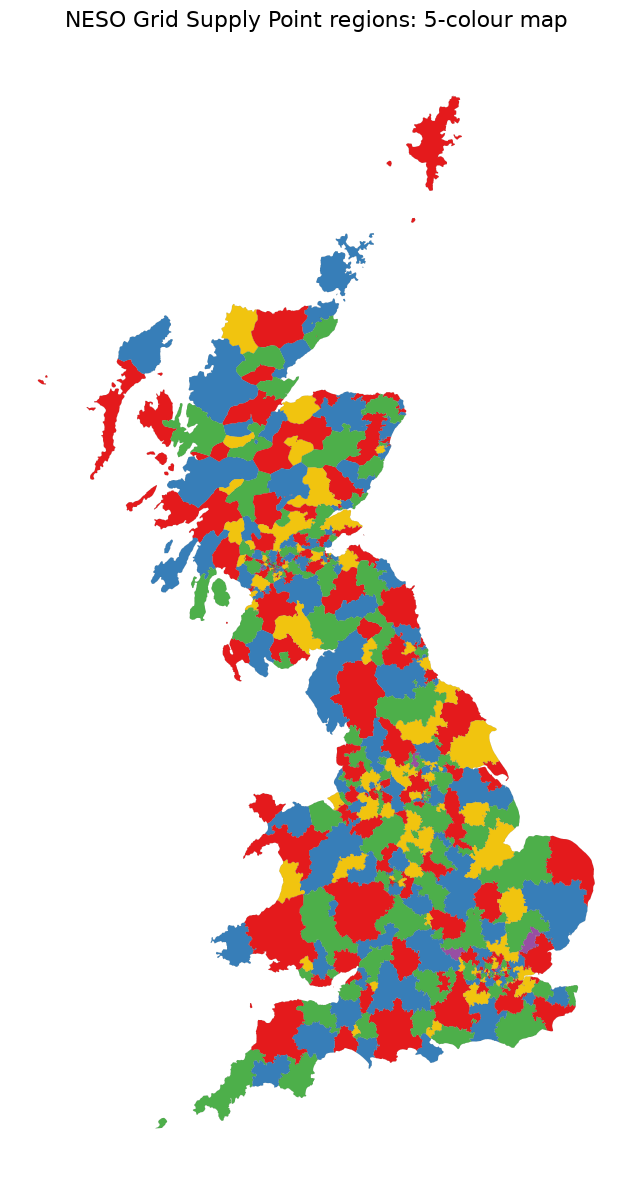

Saved vector map to: ..\data\outputs\visualisations\gsp_regions_colour_coded.svg


In [16]:
output_path = Path("../data/outputs/visualisations/gsp_regions_colour_coded.svg")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.05,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map",
    fontsize=16,
    pad=12,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(output_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved vector map to: {output_path}")

Now to add Met Office GHI instruments onto the map:

Observation batch used: 2026092206
GHI instruments plotted: 86


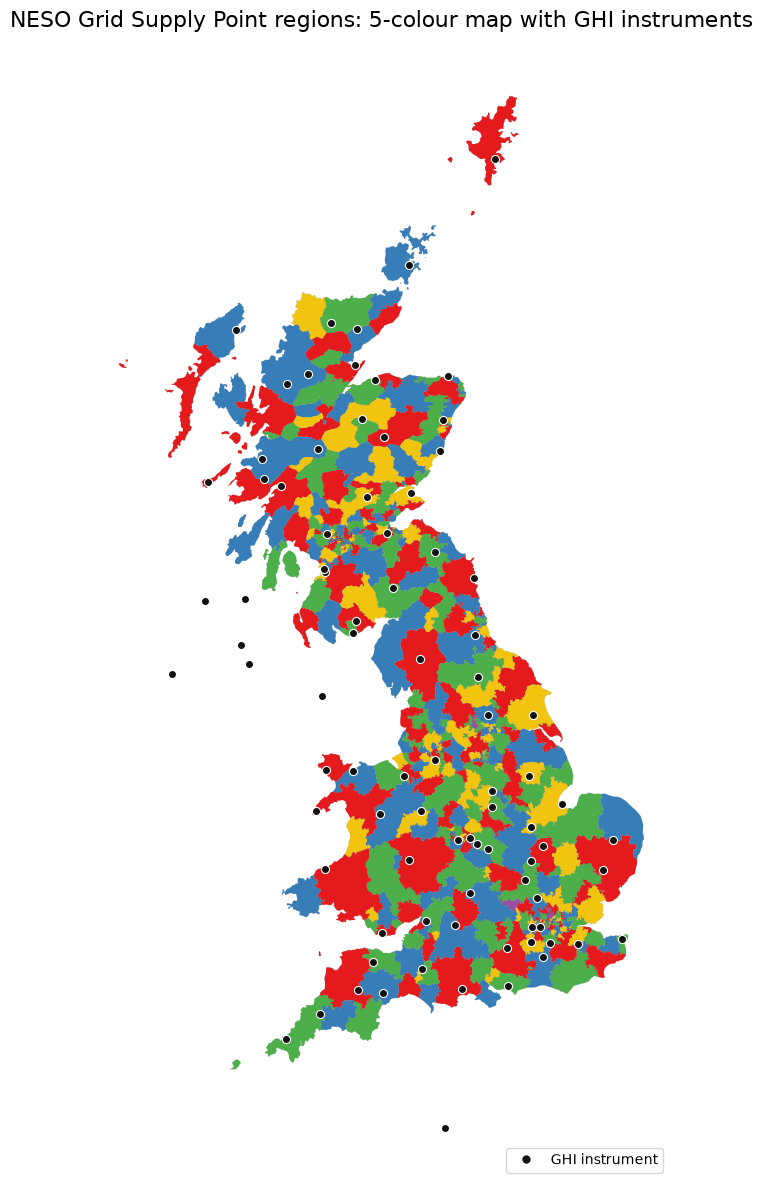

Saved vector map to: ..\data\outputs\visualisations\gsp_regions_with_ghi_instruments.svg


In [7]:
from io import BytesIO
from pathlib import Path

import boto3
import pandas as pd
from botocore import UNSIGNED
from botocore.config import Config
from matplotlib.lines import Line2D

# Use the same public Met Office observation batch as 01_list_bucket.ipynb.
bucket_name = "met-office-land-observations-data"
target_observation_hour = "2026091012"
s3 = boto3.client(
    "s3",
    region_name="eu-west-2",
    config=Config(signature_version=UNSIGNED),
)

paginator = s3.get_paginator("list_objects_v2")
valid_keys = []
observation_hours = set()
for page in paginator.paginate(Bucket=bucket_name):
    for item in page.get("Contents", []):
        parts = item["Key"].split("/")[0].split("_")
        if len(parts) == 3:
            valid_keys.append(item["Key"])
            observation_hours.add(parts[1][:10])

selected_observation_hour = (
    target_observation_hour
    if target_observation_hour in observation_hours
    else max(observation_hours)
)
midday_keys = [
    key for key in valid_keys
    if key.split("/")[0].split("_")[1].startswith(selected_observation_hour)
]
print(f"Observation batch used: {selected_observation_hour}")

ghi_stations = []
for key in midday_keys:
    response = s3.get_object(Bucket=bucket_name, Key=key)
    station_df = pd.read_csv(BytesIO(response["Body"].read()), sep="|")

    if station_df["global_radiation_1_minute_mean"].notna().any():
        ghi_stations.append({
            "name": station_df["name"].iloc[0],
            "latitude": station_df["latitude"].iloc[0],
            "longitude": station_df["longitude"].iloc[0],
        })

ghi_stations = pd.DataFrame(ghi_stations).drop_duplicates("name")
print(f"GHI instruments plotted: {len(ghi_stations)}")

output_path = Path("../data/outputs/visualisations/gsp_regions_with_ghi_instruments.svg")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.05,
)

ax.scatter(
    ghi_stations["longitude"],
    ghi_stations["latitude"],
    s=34,
    c="#111111",
    edgecolors="white",
    linewidths=0.8,
    zorder=5,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map with GHI instruments",
    fontsize=16,
    pad=12,
)
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#111111",
            markeredgecolor="white",
            markersize=7,
            label="GHI instrument",
        )
    ],
    loc="lower right",
    frameon=True,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(output_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved vector map to: {output_path}")

Looks a little weird without NI, ROI, guernsey, isle of man. Let's add those. 

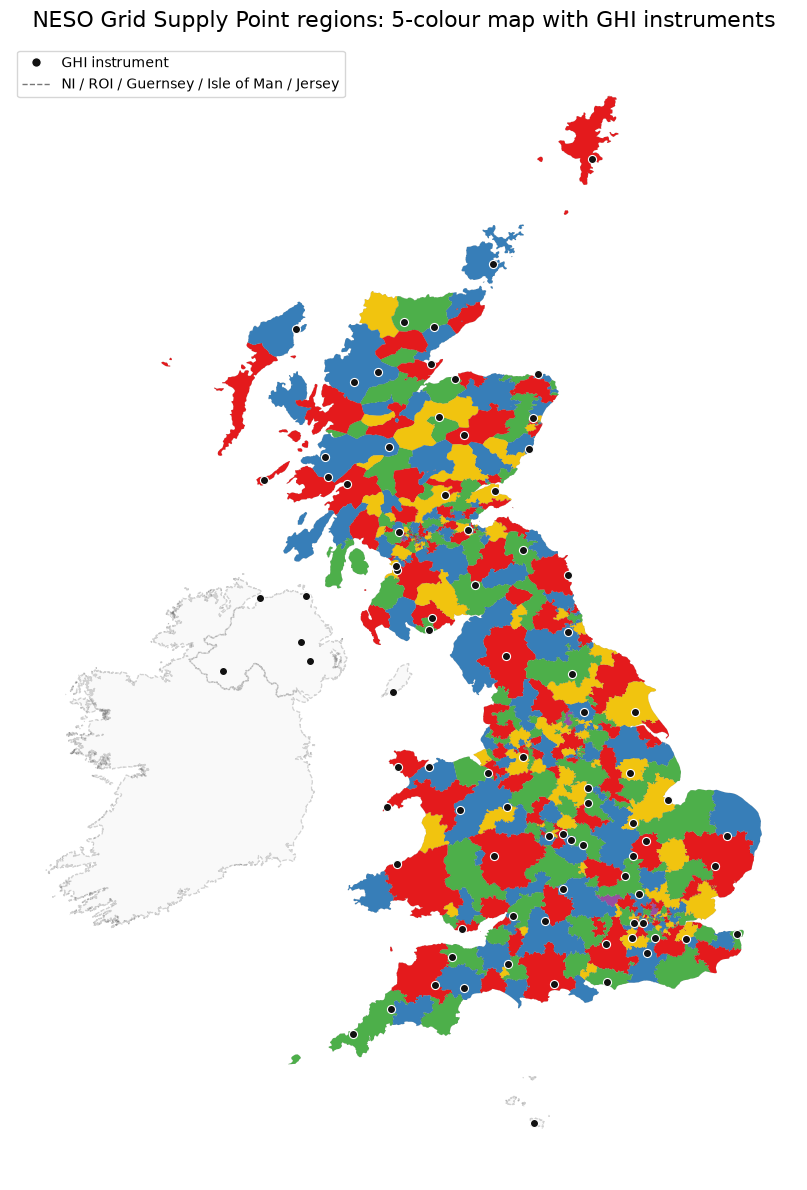

Saved vector map to: ..\data\outputs\visualisations\gsp_regions_with_ghi_and_island_boundaries.svg


In [10]:
from matplotlib.lines import Line2D
from pathlib import Path

# Boundary source: GADM 4.1, https://gadm.org/data.html
# Download endpoints are recorded here so the provenance is visible and reproducible.
boundary_sources = {
    "Northern Ireland": {
        "path": Path("../data/inputs/boundaries/gadm41_GBR_1.json"),
        "url": "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_GBR_1.json",
        "feature_name": "NorthernIreland",
    },
    "Republic of Ireland": {
        "path": Path("../data/inputs/boundaries/gadm41_IRL_0.json"),
        "url": "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IRL_0.json",
        "feature_name": None,
    },
    "Guernsey": {
        "path": Path("../data/inputs/boundaries/gadm41_GGY_0.json"),
        "url": "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_GGY_0.json",
        "feature_name": None,
    },
    "Isle of Man": {
        "path": Path("../data/inputs/boundaries/gadm41_IMN_0.json"),
        "url": "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IMN_0.json",
        "feature_name": None,
    },
    "Jersey": {
        "path": Path("../data/inputs/boundaries/gadm41_JEY_0.json"),
        "url": "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_JEY_0.json",
        "feature_name": None,
    },
}

boundary_layers = {}
for boundary_name, source in boundary_sources.items():
    boundary_layer = gpd.read_file(source["path"])
    if source["feature_name"] is not None:
        boundary_layer = boundary_layer[
            boundary_layer["NAME_1"] == source["feature_name"]
        ]
    boundary_layers[boundary_name] = boundary_layer.to_crs(gsp_regions.crs)

output_path = Path(
    "../data/outputs/visualisations/gsp_regions_with_ghi_and_island_boundaries.svg"
)
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    column="_colour",
    categorical=True,
    cmap=ListedColormap(colours[:number_of_colours]),
    edgecolor="#333333",
    linewidth=0.05,
)

for boundary_layer in boundary_layers.values():
    boundary_layer.plot(
        ax=ax,
        facecolor="#eeeeee",
        edgecolor="#777777",
        alpha=0.32,
        linewidth=0.9,
        linestyle="--",
        zorder=3,
    )

ax.scatter(
    ghi_stations["longitude"],
    ghi_stations["latitude"],
    s=34,
    c="#111111",
    edgecolors="white",
    linewidths=0.8,
    zorder=5,
)

ax.set_title(
    f"NESO Grid Supply Point regions: {number_of_colours}-colour map with GHI instruments",
    fontsize=16,
    pad=12,
)
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#111111",
            markeredgecolor="white",
            markersize=7,
            label="GHI instrument",
        ),
        Line2D(
            [0],
            [0],
            color="#777777",
            linewidth=1,
            linestyle="--",
            label="NI / ROI / Guernsey / Isle of Man / Jersey",
        ),
    ],
    loc="upper left",
    frameon=True,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(output_path, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved vector map to: {output_path}")

Great. Now let's make it clear which GSP regions have at least one instrument within. 

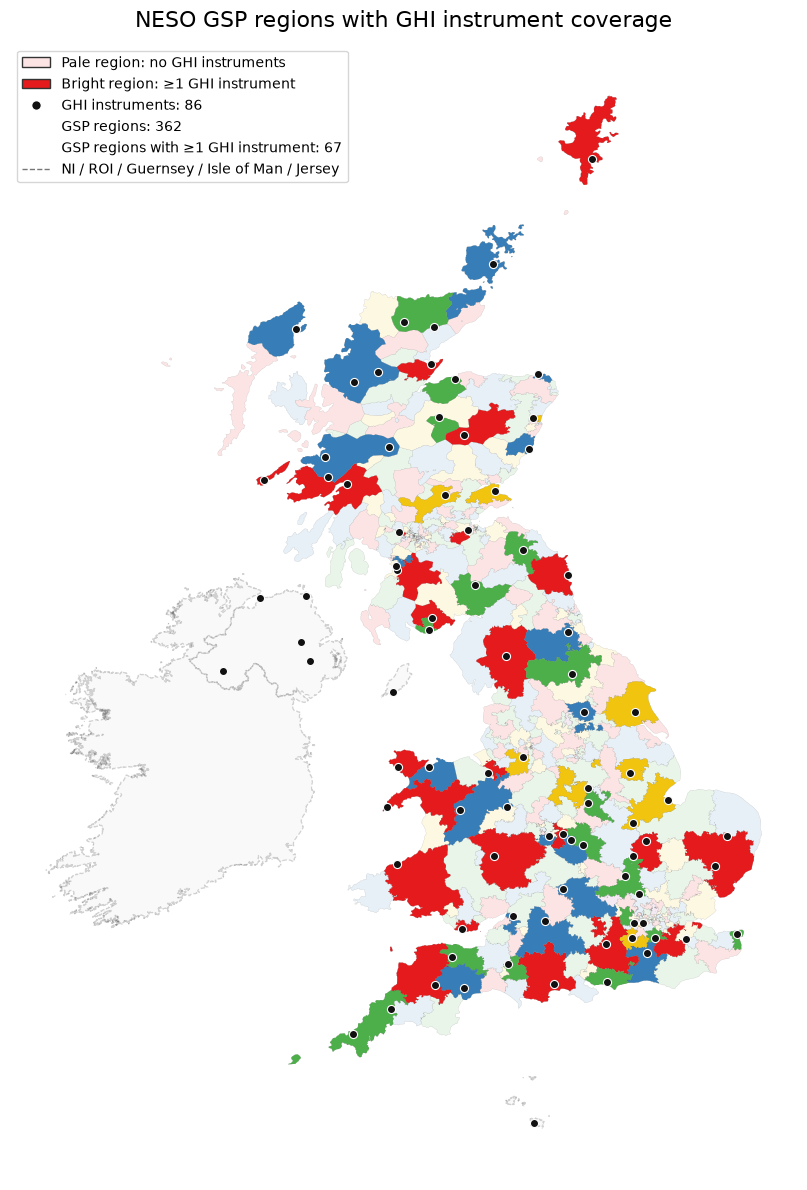

GHI instruments: 86
GSP regions: 362
GSP regions with ≥1 GHI instrument: 67
Saved vector map to: ..\data\outputs\visualisations\gsp_regions_ghi_coverage.svg


In [14]:
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

# Match GHI instruments to GB GSP regions using point-in-polygon containment.
ghi_points = gpd.GeoDataFrame(
    ghi_stations.copy(),
    geometry=gpd.points_from_xy(
        ghi_stations["longitude"],
        ghi_stations["latitude"],
    ),
    crs=gsp_regions.crs,
)
ghi_matches = gpd.sjoin(
    ghi_points,
    plot_data[["geometry"]],
    how="inner",
    predicate="within",
)
instrument_region_indices = set(ghi_matches["index_right"])
regions_with_ghi = plot_data.loc[sorted(instrument_region_indices)]

bright_colours = [to_rgb(colour) for colour in colours[:number_of_colours]]
pale_colours = [
    tuple(1 - 0.12 * (1 - channel) for channel in colour)
    for colour in bright_colours
]
plot_colours = [pale_colours[index] for index in plot_data["_colour"]]
bright_region_colours = [
    bright_colours[index] for index in regions_with_ghi["_colour"]
]

output_path = Path(
    "../data/outputs/visualisations/gsp_regions_ghi_coverage.svg"
)
output_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 12))
plot_data.plot(
    ax=ax,
    color=plot_colours,
    edgecolor="#333333",
    linewidth=0.05,
)
regions_with_ghi.plot(
    ax=ax,
    color=bright_region_colours,
    edgecolor="#333333",
    linewidth=0.05,
    zorder=2,
)

for boundary_layer in boundary_layers.values():
    boundary_layer.plot(
        ax=ax,
        facecolor="#eeeeee",
        edgecolor="#777777",
        alpha=0.32,
        linewidth=0.9,
        linestyle="--",
        zorder=3,
    )

ax.scatter(
    ghi_stations["longitude"],
    ghi_stations["latitude"],
    s=34,
    c="#111111",
    edgecolors="white",
    linewidths=0.8,
    zorder=5,
)

ax.set_title(
    "NESO GSP regions with GHI instrument coverage",
    fontsize=16,
    pad=12,
)
ax.legend(
    handles=[
        Patch(
            facecolor=pale_colours[0],
            edgecolor="#333333",
            label="Pale region: no GHI instruments",
        ),
        Patch(
            facecolor=bright_colours[0],
            edgecolor="#333333",
            label="Bright region: ≥1 GHI instrument",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#111111",
            markeredgecolor="white",
            markersize=7,
            label=f"GHI instruments: {len(ghi_stations)}",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            label=f"GSP regions: {len(plot_data)}",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            label=f"GSP regions with ≥1 GHI instrument: {len(regions_with_ghi)}",
        ),
        Line2D(
            [0],
            [0],
            color="#777777",
            linewidth=1,
            linestyle="--",
            label="NI / ROI / Guernsey / Isle of Man / Jersey",
        ),
    ],
    loc="upper left",
    frameon=True,
)
ax.set_axis_off()
fig.tight_layout()
fig.savefig(output_path, format="svg", bbox_inches="tight")
plt.show()
print(f"GHI instruments: {len(ghi_stations)}")
print(f"GSP regions: {len(plot_data)}")
print(f"GSP regions with ≥1 GHI instrument: {len(regions_with_ghi)}")
print(f"Saved vector map to: {output_path}")

^ note the N=86 number is sensitive to which instruments were experiencing uptime at the exact instance I checked; this can vary.

In [15]:
import json

reference_data_path = Path("../data/outputs/reference_data")
reference_data_path.mkdir(parents=True, exist_ok=True)

# Save the GSP polygons with their stable colour assignment and GHI coverage.
gsp_export = plot_data.copy()
ghi_counts = ghi_matches.groupby("index_right").size()
gsp_export["colour_index"] = gsp_export["_colour"].astype(int)
gsp_export["colour_hex"] = gsp_export["colour_index"].map(
    dict(enumerate(colours[:number_of_colours]))
)
gsp_export["ghi_instrument_count"] = (
    ghi_counts.reindex(gsp_export.index, fill_value=0).astype(int)
)
gsp_export["has_ghi_instrument"] = gsp_export["ghi_instrument_count"] > 0
gsp_export.drop(columns="_colour").to_file(
    reference_data_path / "gsp_regions_with_colour_and_ghi_coverage.geojson",
    driver="GeoJSON",
)

# Save station locations in formats convenient for geospatial and tabular work.
ghi_points.to_file(
    reference_data_path / "ghi_instrument_locations.geojson",
    driver="GeoJSON",
)
ghi_stations.to_csv(
    reference_data_path / "ghi_instrument_locations.csv",
    index=False,
)

# Save the non-GSP reference areas together for reuse in later maps.
boundary_exports = []
for boundary_name, boundary_layer in boundary_layers.items():
    boundary_export = boundary_layer.copy()
    boundary_export["boundary_name"] = boundary_name
    boundary_exports.append(boundary_export[["boundary_name", "geometry"]])
gpd.GeoDataFrame(
    pd.concat(boundary_exports, ignore_index=True),
    crs=gsp_regions.crs,
).to_file(
    reference_data_path / "reference_boundaries.geojson",
    driver="GeoJSON",
)

metadata = {
    "description": "Reusable GSP, GHI instrument, and reference boundary data exported from 02_GSP_regions.ipynb.",
    "crs": gsp_regions.crs.to_string(),
    "gsp_region_count": int(len(gsp_export)),
    "gsp_regions_with_ghi_count": int(gsp_export["has_ghi_instrument"].sum()),
    "ghi_instrument_count": int(len(ghi_stations)),
    "observation_batch": selected_observation_hour,
    "ghi_source": "Public Met Office land observations AWS bucket: met-office-land-observations-data",
    "boundary_source": "GADM 4.1: https://gadm.org/data.html",
    "files": [
        "gsp_regions_with_colour_and_ghi_coverage.geojson",
        "ghi_instrument_locations.geojson",
        "ghi_instrument_locations.csv",
        "reference_boundaries.geojson",
    ],
}
with open(reference_data_path / "README.json", "w", encoding="utf-8") as metadata_file:
    json.dump(metadata, metadata_file, indent=2)

print(f"Reusable reference data saved to: {reference_data_path}")
for file_name in metadata["files"] + ["README.json"]:
    print(f"- {file_name}")

Reusable reference data saved to: ..\data\outputs\reference_data
- gsp_regions_with_colour_and_ghi_coverage.geojson
- ghi_instrument_locations.geojson
- ghi_instrument_locations.csv
- reference_boundaries.geojson
- README.json
